# Reading SmartSolo `DigiSolo.LOG` files

This notebook shows how to use `lib/smartsolo_log.py` to turn SmartSolo node state-of-health logs into pandas DataFrames and plot temperature, battery voltage, GPS position, tilt etc. against time.

In [6]:
import sys
sys.path.insert(0, "../lib")          # make lib/ importable

import pandas as pd
import matplotlib.pyplot as plt
import smartsolo_log as sl

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# the two DML (Dronning Maud Land) nodes used in this notebook
DML_NODES = ["../data/nodes/453021267", "../data/nodes/453022522"]

## 1. One log file → one wide DataFrame
Each log record (`[GPS00018]`, `[Temperature00001]`, ...) is one row; every field is a column. The index is the record's `UTC Time` as a timezone-aware pandas `DatetimeIndex`.

In [7]:
df = sl.read_log("../data/nodes/453021267/DigiSolo.LOG")
print(df.shape)
print(type(df.index), df.index.dtype)
df.head()

(9920, 38)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns, UTC]


,serial,file,record_type,record_no,line_no,session,time_inferred,start_acquisition_filename,gps_status,gps_tick,dac_value,adc_sync_value_1,adc_sync_value_2,phase_error,max_phase_error,leap_second,ecompass_north,tilted_angle,roll_angle,pitch_angle,gps_power,latest_fix_utc_time,satellite_number,gps_strength,satellite_id,longitude,latitude,altitude,rtc_time,temperature,gps_fix,voltage,total_memory,available_memory,used_memory,error_type,access_type,changed_acquisition_filename
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-11-13 04:35:04+00:00,453021267,../data/nodes/453021267/DigiSolo.LOG,BatteryPowerOnStop,NaN,60,1,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-24 13:10:50+00:00,453021267,../data/nodes/453021267/DigiSolo.LOG,BatteryPowerOnStop,NaN,119,2,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-25 14:19:27+00:00,453021267,../data/nodes/453021267/DigiSolo.LOG,Notify,1.0,193,3,False,Seis000.DLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-25 14:20:04+00:00,453021267,../data/nodes/453021267/DigiSolo.LOG,GPS,1.0,197,3,False,NaN,GPS Cycle Off,94.0,2062.0,2907.0,39.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-25 14:26:27+00:00,453021267,../data/nodes/453021267/DigiSolo.LOG,Notify,1.0,278,4,False,Seis001.DLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.dtypes

serial                                       object
file                                         object
record_type                                  object
record_no                                   float64
line_no                                       int64
session                                       int64
time_inferred                                  bool
start_acquisition_filename                   object
gps_status                                   object
gps_tick                                    float64
dac_value                                   float64
adc_sync_value_1                            float64
adc_sync_value_2                            float64
phase_error                                 float64
max_phase_error                             float64
leap_second                                 float64
ecompass_north                              float64
tilted_angle                                float64
roll_angle                                  float64
pitch_angle 

In [9]:
df['record_type'].value_counts()

record_type
GPS                   6855
Temperature           1961
Battery                659
Memory                 426
Notify                   8
Error                    7
BatteryPowerOnStop       4
Name: count, dtype: int64

The first line of teh file holds record counters. They are kept in `df.attrs` so you can check that nothing was lost while parsing.

In [10]:
print("header:", df.attrs["header_counts"])
print("parsed:", df.attrs["parsed_counts"])

header: {'DeviceInfo': 6, 'GPS': 6855, 'Temperature': 1961, 'Memory': 426, 'Battery': 659, 'Error': 7, 'Notify': 1}
parsed: {'GPS': 6855, 'Temperature': 1961, 'Battery': 659, 'Memory': 426, 'Notify': 8, 'Error': 7, 'DeviceInfo': 6, 'BatteryPowerOnStop': 4}


## 2. Quick plots against time
Every column is sparse (only filled for its record type), so `dropna()` before plotting with plain pandas:

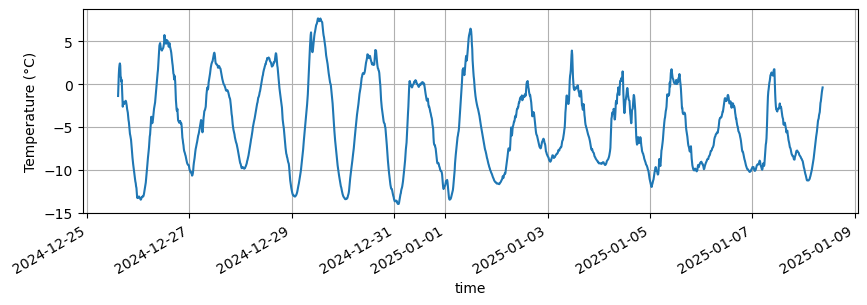

In [11]:
df["temperature"].dropna().plot(figsize=(10, 3), ylabel="Temperature (°C)", grid=True);

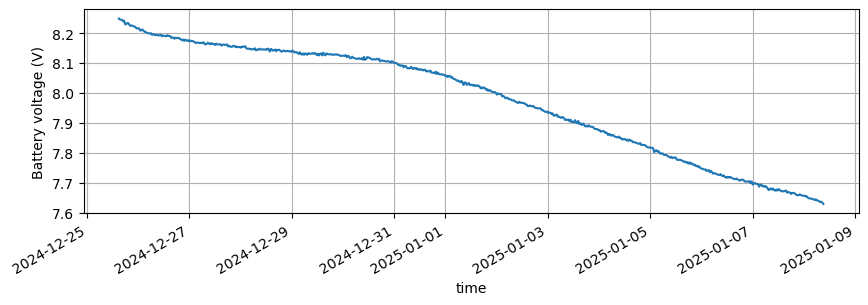

In [12]:
df["voltage"].dropna().plot(figsize=(10, 3), ylabel="Battery voltage (V)", grid=True);

Or use the helper, which draws one subplot per column:

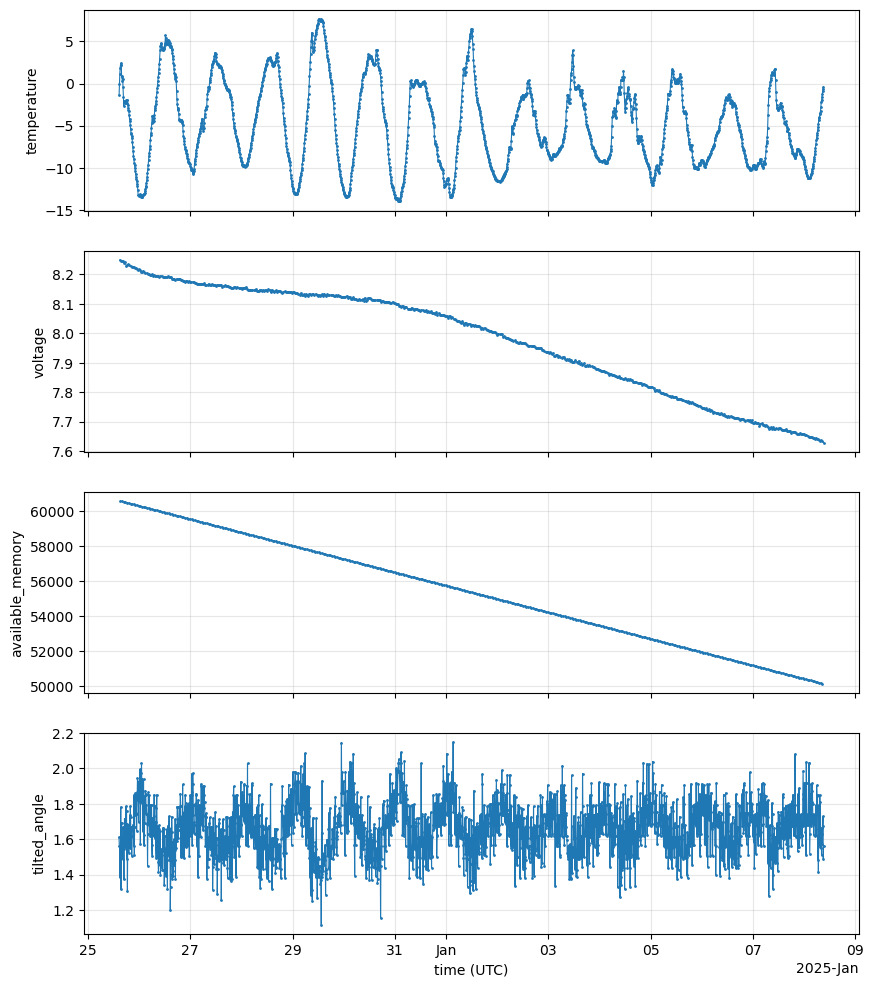

In [13]:
sl.plot_series(df, ["temperature", "voltage", "available_memory", "tilted_angle"]);

Selecting a time window is ordinary pandas datetime indexing:

In [14]:
df.loc["2024-12-26":"2024-12-27", "temperature"].dropna().describe()

count    285.000000
mean      -3.231360
std        5.364187
min      -13.500000
25%       -7.562500
50%       -3.187500
75%        1.625000
max        5.750000
Name: temperature, dtype: float64

Resample, e.g. daily mean temperature and minimum voltage:

In [15]:
daily = pd.DataFrame({
    "temp_mean": df["temperature"].dropna().resample("1D").mean(),
    "volt_min":  df["voltage"].dropna().resample("1D").min(),
})
daily.head(10)

,temp_mean,volt_min
time,,
2024-12-25 00:00:00+00:00,-4.906250,8.2156
2024-12-26 00:00:00+00:00,-3.458479,8.1744
2024-12-27 00:00:00+00:00,-3.002641,8.1532
2024-12-28 00:00:00+00:00,-3.325612,8.1380
2024-12-29 00:00:00+00:00,-2.683979,8.1239
2024-12-30 00:00:00+00:00,-4.239510,8.1016
2024-12-31 00:00:00+00:00,-5.792254,8.0572
2025-01-01 00:00:00+00:00,-5.288899,8.0012
2025-01-02 00:00:00+00:00,-5.693662,7.9373


Pick one record type with only its own columns:

In [16]:
gps_sync = df[df.gps_status == "GPS Synchronization"].dropna(axis=1, how="all")
gps_sync[["latitude", "longitude", "altitude", "satellite_number", "ecompass_north", "tilted_angle"]].describe()

,latitude,longitude,altitude,satellite_number,ecompass_north,tilted_angle
count,2446.000000,2446.000000,2446.000000,2446.000000,2446.000000,2446.000000
mean,-71.548240,11.115704,1648.913410,10.871627,156.669660,1.663493
std,0.000018,0.000033,3.438697,0.945486,0.919565,0.146329
min,-71.548315,11.115561,1639.400000,8.000000,153.167000,1.118000
25%,-71.548249,11.115681,1646.400000,10.000000,156.103250,1.560000
50%,-71.548238,11.115703,1648.600000,11.000000,156.804000,1.671500
75%,-71.548228,11.115725,1651.000000,12.000000,157.316000,1.750750
max,-71.548189,11.115849,1663.300000,12.000000,159.219000,2.149000


Quoted lists (`gps_strength`, `satellite_id`) stay as strings; expand them when needed:

In [17]:
sl.split_list_column(gps_sync, "gps_strength", prefix="snr").head()

,snr_0,snr_1,snr_2,snr_3,snr_4,snr_5,snr_6,snr_7,snr_8,snr_9,snr_10,snr_11
time,,,,,,,,,,,,
2024-12-25 14:34:23+00:00,46,45,43,42,41,39,37,37,37.0,35.0,NaN,NaN
2024-12-25 14:42:31+00:00,48,47,45,45,44,43,41,39,39.0,39.0,33.0,NaN
2024-12-25 14:50:37+00:00,47,46,45,44,44,43,43,41,40.0,39.0,39.0,NaN
2024-12-25 14:58:42+00:00,48,47,46,45,45,44,44,40,40.0,39.0,39.0,NaN
2024-12-25 15:06:51+00:00,47,46,45,44,44,43,43,39,39.0,38.0,38.0,NaN


Errors and acquisition-file notifications:

In [18]:
df.loc[df.record_type.isin(["Error", "Notify", "BatteryPowerOnStop"]),
       ["record_type", "error_type", "start_acquisition_filename", "changed_acquisition_filename", "time_inferred"]]

,record_type,error_type,start_acquisition_filename,changed_acquisition_filename,time_inferred
time,,,,,
2024-11-13 04:35:04+00:00,BatteryPowerOnStop,NaN,NaN,NaN,True
2024-12-24 13:10:50+00:00,BatteryPowerOnStop,NaN,NaN,NaN,True
2024-12-25 14:19:27+00:00,Notify,NaN,Seis000.DLD,NaN,False
2024-12-25 14:26:27+00:00,Notify,NaN,Seis001.DLD,NaN,False
2024-12-25 15:44:43+00:00,Error,SD Driver Error,NaN,NaN,False
2024-12-25 16:35:31+00:00,Error,SD Driver Error,NaN,NaN,False
2024-12-27 14:26:33+00:00,Notify,NaN,NaN,Seis002.DLD,False
2024-12-29 07:41:36+00:00,Error,SD Driver Error,NaN,NaN,False
2024-12-29 07:50:14+00:00,Error,SD Driver Error,NaN,NaN,False


## 3. Several nodes at once
`read_logs` takes a folder, a glob or a list of files. Rows are tagged with the node `serial`.

In [19]:
nodes = sl.read_logs(DML_NODES)
nodes.groupby("serial")["record_type"].value_counts().unstack(0)

serial,453021267,453022522
record_type,,
Battery,659.0,659.0
BatteryPowerOnStop,4.0,3.0
Error,7.0,NaN
GPS,6855.0,6824.0
Memory,426.0,427.0
Notify,8.0,7.0
Temperature,1961.0,1963.0


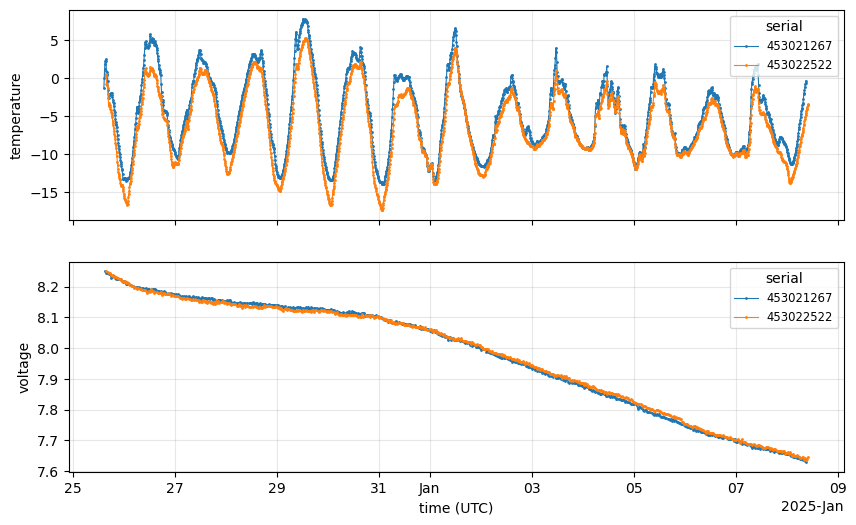

In [20]:
sl.plot_series(nodes, ["temperature", "voltage"], by="serial");

In [21]:
nodes.groupby("serial")[["temperature", "voltage", "latitude", "longitude", "altitude"]].agg(["min", "mean", "max"]).T

serial              453021267    453022522
temperature min    -14.000000   -17.375000
            mean    -4.820117    -6.358635
            max      7.687500     5.187500
voltage     min      7.629400     7.636500
            mean     7.978239     7.978019
            max      8.249300     8.249900
latitude    min    -71.548315   -71.550077
            mean   -71.548240   -71.550001
            max    -71.548189   -71.549440
longitude   min     11.115561    11.117576
            mean    11.115704    11.117694
            max     11.115849    11.119751
altitude    min   1639.400000  1636.600000
            mean  1648.913410  1647.946955
            max   1663.300000  1662.900000

## 4. Device metadata (one row per boot)
The `[DeviceInfoNNNNN]` blocks are written each time a node boots: firmware, acquisition settings, geophone self-test (resistance, natural frequency, damping, sensitivity, noise per channel), SD card and boot-time GPS/tilt/battery. Boots without a `Boot RTC` get `NaT`.

In [22]:
info = sl.read_device_info(DML_NODES)
info[["serial_number", "boot_no", "boot_reason", "device_type", "sample_rate",
      "ch1_resonate_freq", "ch2_resonate_freq", "ch3_resonate_freq",
      "ch1_damping", "booting_temperature", "voltage", "gps_lock_time"]]

,serial_number,boot_no,boot_reason,device_type,sample_rate,ch1_resonate_freq,ch2_resonate_freq,ch3_resonate_freq,ch1_damping,booting_temperature,voltage,gps_lock_time
boot_time,,,,,,,,,,,,
2024-11-13 04:35:04+00:00,453021267,1,0007,IGU-16HR 3C 5Hz,100.0,5.0122,0.0000,4.5552,0.7159,NaN,NaN,NaT
2024-11-13 04:48:52+00:00,453022522,1,0007,IGU-16HR 3C 5Hz,100.0,3.8920,133.1317,4.7184,-0.0210,NaN,NaN,NaT
2024-12-24 12:51:21+00:00,453022522,2,0007,IGU-16HR 3C 5Hz,100.0,5.0984,5.0663,4.9141,0.7680,NaN,NaN,NaT
2024-12-24 13:10:50+00:00,453021267,2,0007,IGU-16HR 3C 5Hz,100.0,3.9373,3.6205,4.9156,0.5271,NaN,NaN,NaT
2024-12-25 14:17:18+00:00,453021267,3,0300,IGU-16HR 3C 5Hz,100.0,0.0000,123.9684,0.0000,0.0000,-3.6875,8.2361,2024-12-25 14:19:29+00:00
2024-12-25 14:25:51+00:00,453021267,4,0300,IGU-16HR 3C 5Hz,100.0,5.0324,5.3071,5.3512,0.7461,-2.1250,8.2315,2024-12-25 14:26:29+00:00
2024-12-25 15:16:13+00:00,453022522,3,0300,IGU-16HR 3C 5Hz,100.0,4.9740,5.2080,4.1105,0.7124,-2.0000,8.2548,2024-12-25 15:20:08+00:00
NaT,453021267,5,0087,IGU-16HR 3C 5Hz,100.0,4.9465,4.8352,4.7638,0.7014,NaN,NaN,NaT
NaT,453021267,6,0087,IGU-16HR 3C 5Hz,100.0,5.1353,225.9743,-384.9871,0.7213,NaN,NaN,NaT


## 5. Export

In [23]:
# nodes.to_csv("soh_all_nodes.csv")
# nodes.to_parquet("soh_all_nodes.parquet")   # needs pyarrow